## 1 - Load and Inspect ##

In [ ]:
import pandas as pd
import numpy as np
from sklearn import decomposition
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import altair as alt

df = pd.read_csv('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/data/processed/matrix.csv')

# Fix the sample column anme if it loaded as unnamed
if 'Unnamed:0' in df.columns:
    df.rename(columns={'Unnamed: 0':'Sample'}, inplace=True)

print(f'Loaded matrix: {df.shape[0]} samples x {df.shape[1]} columns')
df.head(3)

## 2 - Separate Genotypes From Metadata ##

In [ ]:
# The non-SNP columns are metadata, not genetic data
non_snp_cols = ['Sample', 'Population code']

# Drop them to get the pure numeric matrix
df_snps = df.drop(columns=non_snp_cols)

# Convert to numpy for scikit-learn
matrix = df_snps.to_numpy()
print(f'SNP matrix shape (samples x variants): {matrix.shape}')


## 3 - Run PCA

In [7]:
# Fit PCA, asking for 2 components (PC1 and PC2)
pca = decomposition.PCA(n_components=2)
pca.fit(matrix)

# How much variance does each component explain?
print('Variance explained:')
print(f' PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f' PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')

# Project every sample into PC space
to_plot = pca.transform(matrix)
print(f'Projected shape: {to_plot.shape}') 


Variance explained:
 PC1: 8.25%
 PC2: 5.41%
Projected shape: (1092, 2)


## 4 - Quick Sanity-Check Scatter

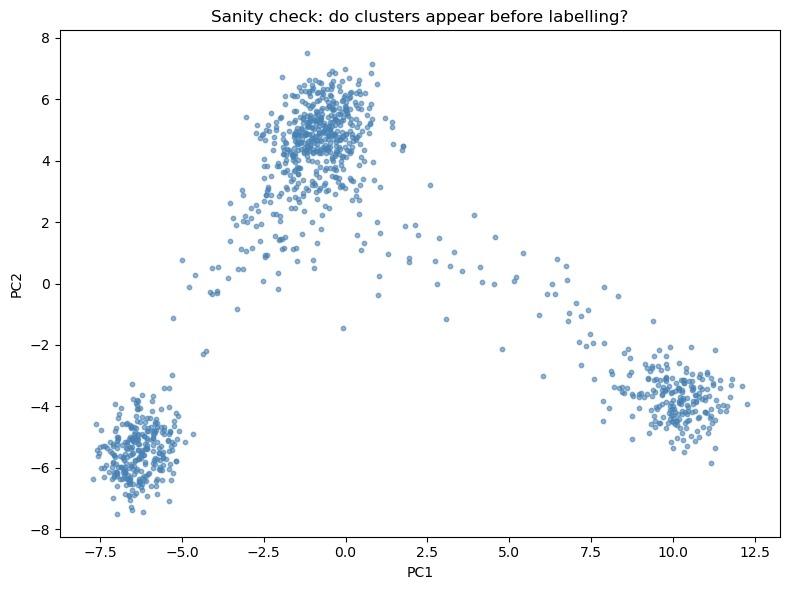

In [8]:
# Plain scatter before adding labels - just to verify clustering
plt.figure(figsize=(8,6))
plt.scatter(to_plot[:,0], to_plot[:,1], s=10, alpha=0.6, color='steelblue')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Sanity check: do clusters appear before labelling?')
plt.tight_layout()
plt.savefig('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_unlabelled.png', dpi=150)
plt.show()

## 5 - Build the Plotting DataFrame With Labels

In [9]:
# Small DataFrame: just metadata plus PC coordinates
df_plot = df[non_snp_cols].copy()
df_plot['PC1'] = to_plot[:, 0]
df_plot['PC2'] = to_plot[:, 1]

# Load population descriptions for super population names
pop = pd.read_csv('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/data/raw/igsr_populations.tsv', sep='\t')

# Merge on population code
df_plot = df_plot.merge(
    pop[['Population code', 'Superpopulation name', 'Population name']],
    on='Population code', how='left'
)

print(df_plot['Superpopulation name'].unique())
df_plot.head()

<StringArray>
[  'European Ancestry', 'East Asian Ancestry',   'American Ancestry',
    'African Ancestry']
Length: 4, dtype: str


,Sample,Population code,PC1,PC2,Superpopulation name,Population name
0,HG00096,GBR,0.312827,5.354349,European Ancestry,British
1,HG00097,GBR,-0.679403,6.183329,European Ancestry,British
2,HG00099,GBR,-0.420710,5.266720,European Ancestry,British
3,HG00100,GBR,-0.805419,5.965095,European Ancestry,British
4,HG00101,GBR,-0.771385,4.332076,European Ancestry,British


## 6 - The Headline Figure: PCA by Superpopulation

In [14]:
chart_super = alt.Chart(df_plot).mark_circle(size=40, opacity=0.75).encode(
    x=alt.X('PC1:Q', title='PC1'),
    y=alt.Y('PC2:Q', title='PC2'),
    color=alt.Color('Superpopulation name:N',
        scale=alt.Scale(scheme='tableau10'),
        legend=alt.Legend(title='Superpopulation')),
    tooltip=['Sample:N', 'Population name:N', 'Superpopulation name:N']
).properties(
    title={'text': 'Human Population Structure — 1000 Genomes Chr 22',
           'subtitle': 'PCA of ~5,000 SNPs from 1,092 individuals'},
    width=600, height=450
).interactive()  # enables pan and zoom

chart_super.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_superpopulation.html')
chart_super

alt.Chart(...)

## 7 - PCA by Individual Population

In [15]:
chart_pop = alt.Chart(df_plot).mark_circle(size=35, opacity=0.70).encode(
    x='PC1:Q', y='PC2:Q',
    color=alt.Color('Population code:N',
        scale=alt.Scale(scheme='category20'),
        legend=alt.Legend(title='Population', columns=2)),
    tooltip=['Sample:N', 'Population code:N', 'Population name:N',
             'Superpopulation name:N']
).properties(title='Structure by individual population',
    width=650, height=480).interactive()

chart_pop.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_population_codes.html')
chart_pop

alt.Chart(...)

## 8 - t-SNE Comparison

In [16]:
# t-SNE for visual comparison only (~2-5 minutes to run)
print('Running t-SNE...')
X_tsne = TSNE(
    n_components=2,
    learning_rate='auto',
    init='pca', # pca init is more stable than random
    random_state=42, # fix the seed for reproducibility
    perplexity=30 # default -- do NOT tune to get a 'nicer' plot
).fit_transform(matrix)

df_plot['tsne1'] = X_tsne[:,0]
df_plot['tsne2'] = X_tsne[:,1]

chart_tsne = alt.Chart(df_plot).mark_circle(size=40, opacity=0.75).encode(
    x='tsne1:Q', y='tsne2:Q',
    color=alt.Color('Superpopulation name:N',
        scale=alt.Scale(scheme='tableau10')),
    tooltip=['Sample:N', 'Population name:N']
).properties(title='t-SNE (perplexity=30) — compare with PCA',
    width=580, height=430).interactive()
 
chart_tsne.save('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/tsne_superpopulation.html')
chart_tsne

Running t-SNE...


alt.Chart(...)

## Saving Static PNG

In [17]:
import vl_convert as vlc

# Convert the superpopulation chart to a static PNG
png_bytes = vlc.vegalite_to_png(chart_super.to_json(), scale=2)
with open('/Users/tim/bioinformatics-portfolio/01b-genes-and-geography/results/figures/pca_superpopulation.png', 'wb') as f:
    f.write(png_bytes)
print('PNG saved for README.')

PNG saved for README.
